#Автоэнкодер
 ⁃ Выберите датасет из torch.dataset, кроме MNIST (мы думаем, что неплохо подойдет CIFAR10 / CIFAR100), обучите на этом датасете вариационный автоэнкодер.

 ⁃ Поэкспериментируйте с архитектурой -числом эпох, глубиной энкодера и декодера, свертками и тд, чтобы минимизировать loss.

Суть этого задания в том, чтобы разобраться с тем, как работает автоэнкодер. Но будет очень круто, если у вас получится на выходе декодера получить изображения, похожие на исходные - не шум.

In [ ]:
import torch
import numpy as np
import os

device = ("cuda" if torch.cuda.is_available() else "cpu") # используем gpu, если есть таковой
device

'cuda'

In [ ]:
from torchvision.datasets import CIFAR10
from torchvision.transforms import ToTensor

train_data = CIFAR10(root='data', train=True, download=True, transform=ToTensor())
test_data = CIFAR10(root='data', train=False, download=True, transform=ToTensor())

train_data.data.shape, test_data.data.shape

Files already downloaded and verified
Files already downloaded and verified


((50000, 32, 32, 3), (10000, 32, 32, 3))

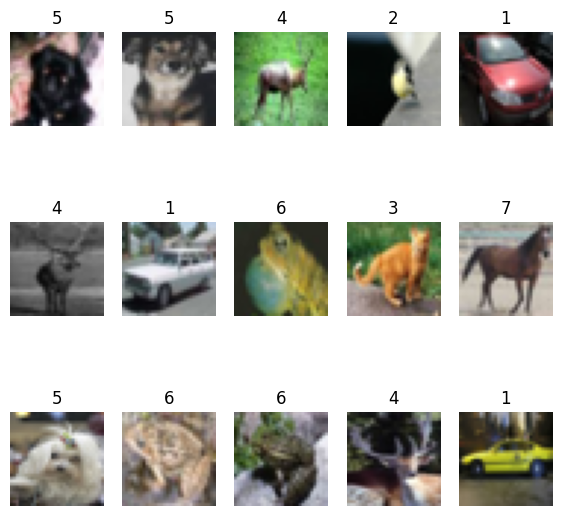

In [ ]:
import matplotlib.pyplot as plt

def visualize(data): # визуализируем датасет
  fig = plt.figure(figsize=(7, 7))

  cols, rows = 5, 3

  for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(data), size=(1,)).item() # рандомная картинка
    img, label = data[sample_idx]

    fig.add_subplot(rows, cols, i)

    plt.title(label)
    plt.axis("off")
    plt.imshow(img.permute(1, 2, 0))

  plt.show()

visualize(train_data) # визуализация

In [ ]:
!pip install torchinfo

In [ ]:
from torch import nn
from torch.nn import functional as F
from torchinfo import summary

class VariationalAutoEncoder(nn.Module): # решил писать сверточно-вариационный авто-энкодер
  def __init__(self, latent_dim=256):
    super().__init__()

    self.encoder = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1), # Для того чтобы продолжать использовать фильтр 3x3 ставим stride=2
        nn.BatchNorm2d(32),
        nn.LeakyReLU(),
        nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
        nn.BatchNorm2d(64),
        nn.LeakyReLU(),
        nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # (128, 4, 4)
        nn.BatchNorm2d(128),
        nn.LeakyReLU(),
        nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
        nn.BatchNorm2d(256),
        nn.LeakyReLU()
    )

    self.flatten = nn.Flatten()
    self.mu = nn.Linear(256 * 2 * 2, latent_dim)
    self.log_variance = nn.Linear(256 * 2 * 2, latent_dim)

    self.decoder_init = nn.Linear(latent_dim, 256 * 2 * 2) # для (128, 4, 4) нам нужно - 128 * 4 * 4 значений, поэтому нужен линейный слой.

    self.decoder = nn.Sequential(
        nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
        nn.BatchNorm2d(128),
        nn.LeakyReLU(),
        nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2), # обратная свертка (128, 4, 4) -> (64, 8, 8)
        nn.BatchNorm2d(64),
        nn.LeakyReLU(),
        nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
        nn.BatchNorm2d(32),
        nn.LeakyReLU(),
        nn.ConvTranspose2d(32, 3, kernel_size=2, stride=2),
        nn.Sigmoid() # чтобы обратно вернуть все пиксели в диапазон [0; 1]
    )

  def reparametrize(self, mu, log_variance):
    std = torch.exp(0.5 * log_variance)
    eps = torch.randn_like(std)
    return mu + std * eps # N(μ, σ²)

  def forward(self, x):
    x = self.encoder(x)
    x = self.flatten(x)
    mu = self.mu(x)
    log_variance = self.log_variance(x)
    z = self.reparametrize(mu, log_variance)
    z = self.decoder_init(z)
    z = z.reshape(-1, 256, 2, 2)
    x = self.decoder(z)
    return x, mu, log_variance

autoencoder = VariationalAutoEncoder().to(device)
print(summary(autoencoder, input_size=(1, 3, 32, 32)))

if torch.cuda.device_count() > 1:
    autoencoder = torch.nn.DataParallel(autoencoder) # распараллеливание работы между GPU


Layer (type:depth-idx)                   Output Shape              Param #
VariationalAutoEncoder                   [1, 3, 32, 32]            --
├─Sequential: 1-1                        [1, 256, 2, 2]            --
│    └─Conv2d: 2-1                       [1, 32, 16, 16]           896
│    └─BatchNorm2d: 2-2                  [1, 32, 16, 16]           64
│    └─LeakyReLU: 2-3                    [1, 32, 16, 16]           --
│    └─Conv2d: 2-4                       [1, 64, 8, 8]             18,496
│    └─BatchNorm2d: 2-5                  [1, 64, 8, 8]             128
│    └─LeakyReLU: 2-6                    [1, 64, 8, 8]             --
│    └─Conv2d: 2-7                       [1, 128, 4, 4]            73,856
│    └─BatchNorm2d: 2-8                  [1, 128, 4, 4]            256
│    └─LeakyReLU: 2-9                    [1, 128, 4, 4]            --
│    └─Conv2d: 2-10                      [1, 256, 2, 2]            295,168
│    └─BatchNorm2d: 2-11                 [1, 256, 2, 2]            51

In [ ]:
class AE_Loss(nn.Module): # обвернул в класс чтобы заработал loss.backward()
    def __init__(self):
        super().__init__()

    def forward(self, x, x_pred, mu, log_variance):
      reconstruction_loss = F.mse_loss(x_pred, x, reduction='sum') # сумма ошибок пикселей.
      kl_divergence = -0.5 * torch.mean(1 + log_variance - mu.pow(2) - log_variance.exp())
      return reconstruction_loss + kl_divergence


from torch import optim
from torch.utils.data import DataLoader

optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.001)
criterion = AE_Loss()

# разделим данные на батчи
batch_size = 64
num_of_epochs = 100

num_workers = min(8, os.cpu_count()) # для многопоточности

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True, persistent_workers=True, prefetch_factor=4) # обучающая выборка
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True, persistent_workers=True, prefetch_factor=4) # тестовая выборка

# persistent_workers позволяет переиспользовать потоки
# pinned_memory позволяет использовать область памяти ОЗУ которая не выгружает ее в диск
# prefetch_factor позволяет во время каждой загрузки, предзагружать еще 4 батча

In [ ]:
!pip install pytorch-ignite

In [ ]:
from ignite.engine import create_supervised_trainer, create_supervised_evaluator
from ignite.metrics import Accuracy, Loss, Precision, Recall, Fbeta
from ignite.engine import Engine, Events

def trainer(engine, batch):
    autoencoder.train() # переводим в режим обучения
    optimizer.zero_grad() # обнуляем градиенты

    imgs, labels = batch
    imgs = imgs.to(device)
    labels = labels.to(device)

    x_pred, mu, log_variance = autoencoder(imgs)

    loss = criterion(imgs, x_pred, mu, log_variance)

    loss.backward()
    optimizer.step()

    return loss.item()

trainer = Engine(trainer)

def evaluator(engine, batch):
    autoencoder.eval()
    with torch.no_grad():
        imgs, _ = batch
        imgs = imgs.to(device)
        x_pred, mu, log_variance = autoencoder(imgs)
        loss = criterion(imgs, x_pred, mu, log_variance)
    return loss.item()

train_evaluator = Engine(evaluator) # проверка на обучающей выборке
test_evaluator = Engine(evaluator) # проверка на тестовой выборке

/usr/local/lib/python3.10/dist-packages/ignite/handlers/checkpoint.py:16: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import ZeroRedundancyOptimizer


In [ ]:
from IPython.display import clear_output

def show_loss(train_losses, test_losses):
  clear_output()

  plt.figure(figsize=(12,5))

  plt.subplot(1, 2, 1)
  plt.title('Train Loss')
  plt.plot(np.arange(len(train_losses)), train_losses)  # лосс обучающей выборки
  plt.yscale('log')
  plt.grid()
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.title('Test Loss')
  plt.plot(np.arange(len(test_losses)), test_losses) # лосс тестовой выборки
  plt.yscale('log')
  plt.grid()
  plt.legend()

  plt.show()


In [ ]:
from ignite.engine import Events


train_losses = []
test_losses = []


def compute_epoch_results(engine):
    print(f"Computing... LR: {optimizer.param_groups[0]['lr']}, LOSS: {test_evaluator.state.output}")
    train_evaluator.run(train_loader)
    test_evaluator.run(test_loader)
    # Сохраняем метрики
    train_loss = train_evaluator.state.output
    test_loss = test_evaluator.state.output

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    scheduler.step(test_loss)

trainer.add_event_handler(Events.EPOCH_COMPLETED, compute_epoch_results)

trainer.add_event_handler(
    Events.EPOCH_COMPLETED(every=10),
    lambda engine: show_loss(train_losses, test_losses)
)

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
from ignite.handlers import EarlyStopping

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=3,
    threshold=0.05,
)


early_stopping = EarlyStopping(patience=10,  score_function=lambda engine: -engine.state.output, trainer=trainer) # для своевременной остановки если не было улучшений

test_evaluator.add_event_handler(Events.COMPLETED, early_stopping) # если при запуске валидации не было улучшений останавливаем

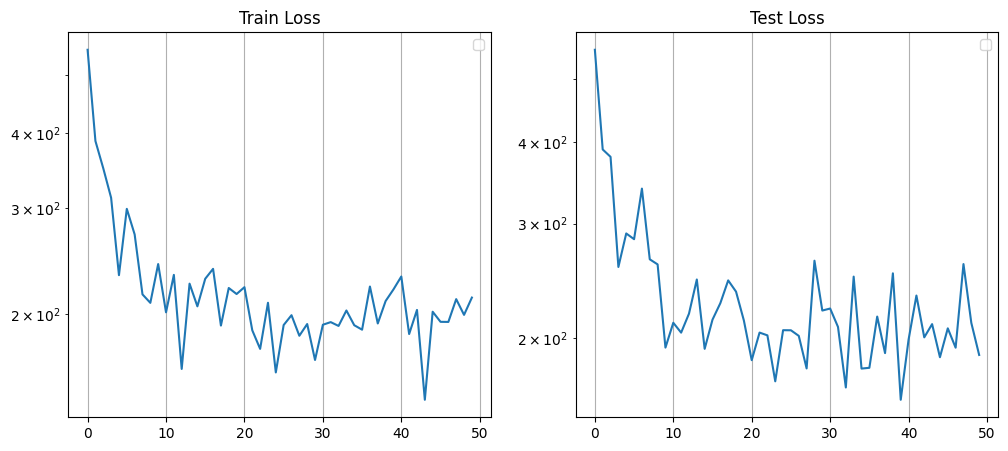

State:
	iteration: 39100
	epoch: 50
	epoch_length: 782
	max_epochs: 100
	output: 280.3567810058594
	batch: <class 'list'>
	metrics: <class 'dict'>
	dataloader: <class 'torch.utils.data.dataloader.DataLoader'>
	seed: <class 'NoneType'>
	times: <class 'dict'>

In [ ]:
trainer.run(train_loader, max_epochs=num_of_epochs)

In [ ]:
# теперь посмотрим на результаты...
def show_final_results(model, dataloader):
  fig = plt.figure(figsize=(12, 7))

  N = 9 # rows * cols фото

  model.eval() # режим оценки

  with torch.no_grad():
    img, label = next(iter(dataloader))
    for i in range(N):
      fig.add_subplot(2, N, i + 1)

      plt.title("Orig")
      plt.axis("off")
      plt.imshow(img[i].permute(1, 2, 0))


    img = img[:N].to(device) # переведем первые несколько фото в gpu
    x_predicted = model(img)[0] # предсказываем

    for i in range(N):
      fig.add_subplot(2, N, N + i + 1)

      plt.title("Pred")
      plt.axis("off")
      plt.imshow(x_predicted[i].cpu().permute(1, 2, 0))

  plt.show()

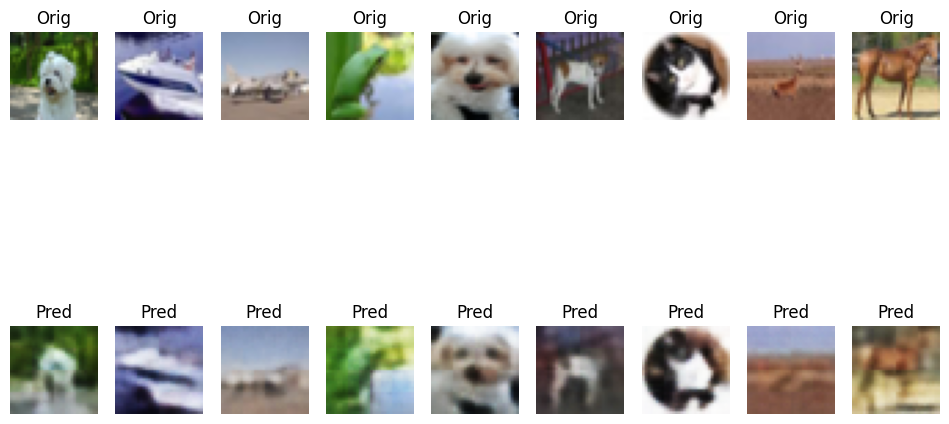

In [ ]:
show_final_results(autoencoder, test_loader)

Вывод:

Изначально размер латентного пространства был установлен на 64, однако результаты оказались неутешительными, и изображения были сильно заблюрены. После изменения размера с 64 до 128, результаты улучшились, но всё равно оставались далеки от чего-то нормального. И, наконец, когда я увеличил размер латентного пространства до 256, изображения стали более-менее похожи на исходные. Также я добавил BatchNorm в модель, чтобы уменьшить размытие и сделать обучение более стабильным. Однако, стабильности в обучении, как таковой, не было замечено. Возможно, проблема заключается в функции лосса.


Также я использовал сверточную архитектуру, чтобы учитывались расположения пикселей в пространстве, в отличии от полносвязной нейросети где они не учитываются.